In [11]:
library(pROC)
library(caret)
library(dplyr)
library(glmnet)
library(parallel)
library(ggplot2)

Type 'citation("pROC")' for a citation.


Attaching package: ‘pROC’


The following objects are masked from ‘package:stats’:

    cov, smooth, var


Loading required package: ggplot2

Warning message:
“package ‘ggplot2’ was built under R version 4.3.3”
Loading required package: lattice


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: Matrix

Loaded glmnet 4.1-8



In [2]:
load("/vol/projects/yzhang/500FG_aging/output/07_cellcounts/cellcounts_prediction(lessrawdata)_spearman.Rdata")

In [2]:
cellCounts = read.table("/vol/projects/CIIM/cohorts_old/500FG/Molecular_phenotype/500FG_inverse_rank_normalized_cellcounts.txt", header = TRUE, stringsAsFactors = FALSE)
head(cellCounts)
dim(cellCounts)
any(is.na(cellCounts))

,IT1,IT2,IT3,IT4,IT5,IT7,IT8,IT9,IT11,IT12,⋯,IT84,IT85,IT86,IT87,IT88,IT89,IT90,IT93,IT94,IT95
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
HV003,-0.7045564,-0.4783576,-0.3823108,-0.0522959,-0.1945046,-1.1736302,-2.8877786,-0.32023844,0.01580384,-0.8775032,⋯,-0.1304413,0.41124576,-0.16485366,-0.12063932,0.3023744,-0.7108026,-1.4626983,-0.6798409,-0.9590444,0.1673187
HV004,2.4682104,0.3433585,0.5761697,-0.3614678,-0.4783576,-0.6615738,1.0267065,-0.57904232,0.41124576,-0.5848020,⋯,0.4920324,0.89551086,-0.06690952,-0.14025590,0.2218351,-0.3823108,-0.5336287,0.1623896,0.1623896,0.2468250
HV005,0.2118786,-1.3576090,-1.2549268,-0.5963799,-0.7553342,-0.3927943,0.1230887,0.98635829,0.75857199,-0.8081388,⋯,1.0267065,0.04986147,-0.46748183,0.21685414,-0.2593771,-0.2543515,-1.1736302,-0.6021990,-0.6859803,0.2019431
HV006,-0.6435248,-0.9982921,-0.8014168,-1.0818022,-1.4626983,-0.5336287,-0.6080384,0.01094088,0.15746453,-0.4458936,⋯,-0.5963799,0.19202751,-1.60437056,-1.25492680,-1.0308337,-1.5375801,-1.7648168,-0.3718691,-0.6525227,-0.6021990
HV007,-0.8632995,-1.1736302,-0.8562626,-1.3824671,-1.0994290,-1.6994536,-0.1206393,-1.27659327,-1.12652869,-1.6791979,⋯,-1.5219124,-0.29474822,-2.15658740,-2.10931320,-1.3824671,-2.4200373,-2.5228989,-1.2338339,-2.3377804,-1.1174042
HV008,-0.4620647,-0.6375551,-0.5733018,-1.1083718,-0.7880801,-0.9982921,-0.9361896,0.40068536,-1.08180216,-0.8148976,⋯,0.1821308,-0.85626255,0.12308870,-0.00850951,0.1771891,0.1084030,-0.1994624,-0.4458936,0.3485208,-1.0391412


[1] 515  73

[1] FALSE

In [3]:
#common_samples <- readRDS("/vol/projects/yzhang/500FG_aging/code/prediction/prediction_vari_spearman/multi-omics_common_sample_without_microbiome.rds") 
common_samples <- readRDS("/vol/projects/yzhang/500FG_aging/input/prediction/alllayer_common_samples_nogenptype.rds")
cellCounts <- cellCounts[common_samples, , drop = FALSE]
dim(cellCounts)
head(cellCounts)

[1] 186  73

,IT1,IT2,IT3,IT4,IT5,IT7,IT8,IT9,IT11,IT12,⋯,IT84,IT85,IT86,IT87,IT88,IT89,IT90,IT93,IT94,IT95
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
HV022,0.7914011,-1.4214391,-1.1932188,-2.0663305,-1.3454886,-0.5733018,-0.8014168,0.90279570,-1.4082101,-0.7045564,⋯,-0.8918862,-1.2765933,-1.1265287,-1.7204316,-0.6316080,-1.35760902,-1.6406363,-0.92122108,-1.24431117,-0.91381371
HV028,-1.4626983,-0.9138137,-0.7683336,-0.6921458,-0.7233789,-1.0391412,-0.9824115,-0.85626255,-1.4349217,-0.6615738,⋯,-0.6859803,-1.7883793,-1.2656858,-2.0663305,-0.8216938,-1.39522303,-2.1565874,-1.08180216,-1.25492680,-2.20923789
HV029,-0.1994624,-1.0559750,-1.1357479,0.2518411,0.3640644,-2.0268573,-0.6256831,0.20690830,-0.4458936,-2.0268573,⋯,0.7847678,-1.6222367,-1.6222367,-1.2765933,-0.7814641,-2.15658740,-1.4770202,0.08885776,-0.73926217,0.00121563
HV030,-0.5905811,-0.2593771,-0.7297101,1.8005428,-0.3100183,0.0255310,-0.8846718,0.75857199,-2.0663305,0.2168541,⋯,-0.5448757,-1.8942192,-0.3459385,-0.6859803,0.4112458,-1.67919790,-1.5870023,-0.37708482,-1.10837184,-0.25435145
HV031,-0.4191962,0.1673187,0.1378010,0.8597757,-0.1796594,-0.4838166,-0.2543515,0.02066717,-0.4947784,-0.3614678,⋯,-1.8942192,-0.4838166,-1.0645052,-0.6706793,-0.8081388,-0.75533418,-0.9745633,-0.13044134,-0.90645614,-0.14516819
HV033,0.5030389,-0.9361896,-1.1736302,-0.5618770,-0.1895516,0.7914011,0.2820756,0.37447569,1.5956263,0.9324279,⋯,1.8257014,1.3395018,-0.1255388,-0.3875472,-0.1599266,0.01094088,-0.8285281,0.50856492,0.08885776,-0.08641714


In [4]:
basicPhenos = read.csv("/vol/projects/yzhang/500FG_aging/output/02_Olink/Age_group_basicPhenos.csv")
# prepare cytokine_filter and pheno_filter_match
idx = intersect(rownames(cellCounts), basicPhenos$ID_500fg) 
length(idx) #458samples
cellCounts_filter = cellCounts[which(rownames(cellCounts) %in% idx),]
head(cellCounts_filter)  #458samples,1596 metabolite
dim(cellCounts_filter)

basicPhenos_filter = basicPhenos %>% filter(ID_500fg %in% idx)
head(basicPhenos_filter) #458samples
dim(basicPhenos_filter)

sum(rownames(cellCounts_filter) == basicPhenos_filter$ID_500fg)

basicPhenos_filter_match = basicPhenos_filter[match(rownames(cellCounts_filter), basicPhenos_filter$ID_500fg), ]

sum(basicPhenos_filter_match$ID_500fg == rownames(cellCounts))
head(basicPhenos_filter_match) 
dim(basicPhenos_filter_match) #458samples
#write.csv(cellCounts_filter, file = "/vol/projects/yzhang/500FG_aging/input/cellCounts/common_cellCounts_filter_age(lessrawdata).csv")
#write.csv(basicPhenos_filter_match, file = "/vol/projects/yzhang/500FG_aging/input/cellCounts/common_basicPhenos_filter_match_cellCounts_age(lessrawdata).csv")

[1] 186

,IT1,IT2,IT3,IT4,IT5,IT7,IT8,IT9,IT11,IT12,⋯,IT84,IT85,IT86,IT87,IT88,IT89,IT90,IT93,IT94,IT95
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
HV022,0.7914011,-1.4214391,-1.1932188,-2.0663305,-1.3454886,-0.5733018,-0.8014168,0.90279570,-1.4082101,-0.7045564,⋯,-0.8918862,-1.2765933,-1.1265287,-1.7204316,-0.6316080,-1.35760902,-1.6406363,-0.92122108,-1.24431117,-0.91381371
HV028,-1.4626983,-0.9138137,-0.7683336,-0.6921458,-0.7233789,-1.0391412,-0.9824115,-0.85626255,-1.4349217,-0.6615738,⋯,-0.6859803,-1.7883793,-1.2656858,-2.0663305,-0.8216938,-1.39522303,-2.1565874,-1.08180216,-1.25492680,-2.20923789
HV029,-0.1994624,-1.0559750,-1.1357479,0.2518411,0.3640644,-2.0268573,-0.6256831,0.20690830,-0.4458936,-2.0268573,⋯,0.7847678,-1.6222367,-1.6222367,-1.2765933,-0.7814641,-2.15658740,-1.4770202,0.08885776,-0.73926217,0.00121563
HV030,-0.5905811,-0.2593771,-0.7297101,1.8005428,-0.3100183,0.0255310,-0.8846718,0.75857199,-2.0663305,0.2168541,⋯,-0.5448757,-1.8942192,-0.3459385,-0.6859803,0.4112458,-1.67919790,-1.5870023,-0.37708482,-1.10837184,-0.25435145
HV031,-0.4191962,0.1673187,0.1378010,0.8597757,-0.1796594,-0.4838166,-0.2543515,0.02066717,-0.4947784,-0.3614678,⋯,-1.8942192,-0.4838166,-1.0645052,-0.6706793,-0.8081388,-0.75533418,-0.9745633,-0.13044134,-0.90645614,-0.14516819
HV033,0.5030389,-0.9361896,-1.1736302,-0.5618770,-0.1895516,0.7914011,0.2820756,0.37447569,1.5956263,0.9324279,⋯,1.8257014,1.3395018,-0.1255388,-0.3875472,-0.1599266,0.01094088,-0.8285281,0.50856492,0.08885776,-0.08641714


[1] 186  73

,X,ID_500fg,Gender,Age,Height,Weight,BMI,LivingSituation,Education,Ethnicity,FarmAnimal,Pets,Travel,DayInMonth,monthinYear,dayInYear,year,AgeGroup
,<int>,<chr>,<chr>,<int>,<int>,<int>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<chr>
1,16,HV515,male,18,170,62,21.45329,Cohabitation,University student,European,Once a month,No,Yes,8,12,338,2014,Group 1
2,41,HV518,male,18,180,67,20.67901,Single living alone,University student,European,Rarely,No,No,1,12,331,2014,Group 1
3,51,HV314,male,18,181,74,22.58783,Married,Middelbaar beroepsonderwijs (MBO),European,Never,No,No,24,11,324,2014,Group 1
4,148,HV454,female,18,167,50,17.92822,Married,University student,European,Rarely,No,Yes,20,10,290,2014,Group 1
5,151,HV461,male,18,183,73,21.79820,Married,University student,European,Rarely,Yes,Yes,20,10,290,2014,Group 1
6,207,HV054,male,18,182,64,19.32134,Married,University student,European,Never,No,No,30,9,270,2013,Group 1


[1] 186  18

[1] 1

[1] 186

,X,ID_500fg,Gender,Age,Height,Weight,BMI,LivingSituation,Education,Ethnicity,FarmAnimal,Pets,Travel,DayInMonth,monthinYear,dayInYear,year,AgeGroup
,<int>,<chr>,<chr>,<int>,<int>,<int>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<chr>
39,196,HV022,female,20,152,45,19.47715,Cohabitation,Middelbaar beroepsonderwijs (MBO),European,Rarely,No,No,3,10,273,2013,Group 2
164,203,HV028,female,29,170,62,21.45329,Single living alone,Middelbaar beroepsonderwijs (MBO),European,Once a month,No,No,30,9,270,2013,Group 5
127,180,HV029,male,24,188,97,27.44455,Married,Hogeschool opleiding (HBO),European,Daily,Yes,No,7,10,277,2013,Group 4
145,197,HV030,female,25,161,57,21.98989,Single living alone,Hogeschool opleiding (HBO),European,Never,No,No,3,10,273,2013,Group 4
64,181,HV031,female,21,180,66,20.37037,Married,University student,European,Once a month,Yes,No,7,10,277,2013,Group 2
59,162,HV033,female,21,165,63,23.14050,Married,University student,European,Rarely,No,No,14,10,284,2013,Group 2


[1] 186  18

In [5]:
cellCounts_age <- cbind(cellCounts_filter, Age = basicPhenos_filter_match$Age)
head(cellCounts_age)
dim(cellCounts_age)

,IT1,IT2,IT3,IT4,IT5,IT7,IT8,IT9,IT11,IT12,⋯,IT85,IT86,IT87,IT88,IT89,IT90,IT93,IT94,IT95,Age
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
HV022,0.7914011,-1.4214391,-1.1932188,-2.0663305,-1.3454886,-0.5733018,-0.8014168,0.90279570,-1.4082101,-0.7045564,⋯,-1.2765933,-1.1265287,-1.7204316,-0.6316080,-1.35760902,-1.6406363,-0.92122108,-1.24431117,-0.91381371,20
HV028,-1.4626983,-0.9138137,-0.7683336,-0.6921458,-0.7233789,-1.0391412,-0.9824115,-0.85626255,-1.4349217,-0.6615738,⋯,-1.7883793,-1.2656858,-2.0663305,-0.8216938,-1.39522303,-2.1565874,-1.08180216,-1.25492680,-2.20923789,29
HV029,-0.1994624,-1.0559750,-1.1357479,0.2518411,0.3640644,-2.0268573,-0.6256831,0.20690830,-0.4458936,-2.0268573,⋯,-1.6222367,-1.6222367,-1.2765933,-0.7814641,-2.15658740,-1.4770202,0.08885776,-0.73926217,0.00121563,24
HV030,-0.5905811,-0.2593771,-0.7297101,1.8005428,-0.3100183,0.0255310,-0.8846718,0.75857199,-2.0663305,0.2168541,⋯,-1.8942192,-0.3459385,-0.6859803,0.4112458,-1.67919790,-1.5870023,-0.37708482,-1.10837184,-0.25435145,25
HV031,-0.4191962,0.1673187,0.1378010,0.8597757,-0.1796594,-0.4838166,-0.2543515,0.02066717,-0.4947784,-0.3614678,⋯,-0.4838166,-1.0645052,-0.6706793,-0.8081388,-0.75533418,-0.9745633,-0.13044134,-0.90645614,-0.14516819,21
HV033,0.5030389,-0.9361896,-1.1736302,-0.5618770,-0.1895516,0.7914011,0.2820756,0.37447569,1.5956263,0.9324279,⋯,1.3395018,-0.1255388,-0.3875472,-0.1599266,0.01094088,-0.8285281,0.50856492,0.08885776,-0.08641714,21


[1] 186  74

In [4]:
basicPhenos_filter_match$Gender <- trimws(as.character(basicPhenos_filter_match$Gender))
basicPhenos_filter_match$Gender[basicPhenos_filter_match$Gender == ""] <- NA

id2gender <- setNames(basicPhenos_filter_match$Gender, basicPhenos_filter_match$ID_500fg)
cellCounts_age$Gender <- id2gender[rownames(cellCounts_age)]

head(cellCounts_age)
dim(cellCounts_age)

,IT1,IT2,IT3,IT4,IT5,IT7,IT8,IT9,IT11,IT12,⋯,IT86,IT87,IT88,IT89,IT90,IT93,IT94,IT95,Age,Gender
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<chr>
HV003,-0.7045564,-0.4783576,-0.3823108,-0.0522959,-0.1945046,-1.1736302,-2.8877786,-0.32023844,0.01580384,-0.8775032,⋯,-0.16485366,-0.12063932,0.3023744,-0.7108026,-1.4626983,-0.6798409,-0.9590444,0.1673187,24,female
HV004,2.4682104,0.3433585,0.5761697,-0.3614678,-0.4783576,-0.6615738,1.0267065,-0.57904232,0.41124576,-0.5848020,⋯,-0.06690952,-0.14025590,0.2218351,-0.3823108,-0.5336287,0.1623896,0.1623896,0.2468250,20,female
HV005,0.2118786,-1.3576090,-1.2549268,-0.5963799,-0.7553342,-0.3927943,0.1230887,0.98635829,0.75857199,-0.8081388,⋯,-0.46748183,0.21685414,-0.2593771,-0.2543515,-1.1736302,-0.6021990,-0.6859803,0.2019431,22,female
HV006,-0.6435248,-0.9982921,-0.8014168,-1.0818022,-1.4626983,-0.5336287,-0.6080384,0.01094088,0.15746453,-0.4458936,⋯,-1.60437056,-1.25492680,-1.0308337,-1.5375801,-1.7648168,-0.3718691,-0.6525227,-0.6021990,24,female
HV007,-0.8632995,-1.1736302,-0.8562626,-1.3824671,-1.0994290,-1.6994536,-0.1206393,-1.27659327,-1.12652869,-1.6791979,⋯,-2.15658740,-2.10931320,-1.3824671,-2.4200373,-2.5228989,-1.2338339,-2.3377804,-1.1174042,23,male
HV008,-0.4620647,-0.6375551,-0.5733018,-1.1083718,-0.7880801,-0.9982921,-0.9361896,0.40068536,-1.08180216,-0.8148976,⋯,0.12308870,-0.00850951,0.1771891,0.1084030,-0.1994624,-0.4458936,0.3485208,-1.0391412,25,male


[1] 508  75

In [7]:
# Create directory to store results
dir.create("/vol/projects/yzhang/500FG_aging/input/prediction/spearman_prediction/cellcounts_spearman_preparation", showWarnings = FALSE)

# Initialize list to store all iterations results
all_results <- list()

# Function to train and evaluate
train_and_evaluate <- function(data, seed, iteration) {
  set.seed(seed)
  
  # Split data
  split_indices <- createDataPartition(data$Age, p = 0.7, list = FALSE)
  training <- data[split_indices, ]
  validation <- data[-split_indices, ]
  print(dim(training))  # Should have ~70% of the original rows
  # Should be 5000 (excluding Age) 
 
  # Get feature names
  feature_names <- setdiff(names(training), "Age")  
  feature_batches <- split(feature_names, ceiling(seq_along(feature_names) / 500))  
    print(length(feature_names))

  RNGkind("L'Ecuyer-CMRG")
  set.seed(123)
    
  # Compute Spearman correlation
  spearman_results <- lapply(feature_batches, function(batch) {
    sapply(batch, function(feature) {
      if (!feature %in% names(training)) return(c(cor = NA, pvalue = NA))
      if (var(training[[feature]], na.rm = TRUE) == 0) return(c(cor = NA, pvalue = NA))
      
      test <- tryCatch(
        cor.test(training[[feature]], training$Age, method = "spearman"),
        error = function(e) return(NULL)
      )

      if (is.null(test)) return(c(cor = NA, pvalue = NA))
      return(c(cor = test$estimate, pvalue = test$p.value))
    }, simplify = FALSE)
  })
       if (length(spearman_results) == 0 || is.null(spearman_results[[1]])) {
    stop("Error: spearman_results is empty or NULL. Check execution.")
  }
  print(length(spearman_results))
  # Extract p-values
  spearman_pvalues <- unlist(lapply(spearman_results, function(batch) {
    sapply(batch, function(x) if (!is.null(x)) x["pvalue"] else NA)
  }))
   print(summary(spearman_pvalues))  

  # Get corresponding feature names
  #feature_names <- names(spearman_pvalues)
 # names(spearman_pvalues) <- feature_names
   feature_names <- unlist(lapply(spearman_results, names))
  print(length(spearman_pvalues))  # p-value 总数
  print(head(spearman_pvalues))    # 预览前几个 p-values
  print(names(spearman_pvalues)[1:10])       
 
 
if (length(feature_names) != length(spearman_pvalues)) {
    stop("Error: Mismatch between feature names and spearman_pvalues length.")
  }
   names(spearman_pvalues) <- feature_names
  
    # Filter features with p-value < 0.05
   selected_features <- names(spearman_pvalues[spearman_pvalues < 0.05])        
  
  # Store results in list
  results <- list(
    split_indices = split_indices,
    selected_features = selected_features,
    spearman_pvalues = spearman_pvalues[selected_features] # 只存筛选出的 p-value
  )

  rm(training, validation, feature_batches, spearman_results, spearman_pvalues, feature_names)
  gc()  

  return(results)
}

           
# Run 100 iterations
#for (i in 1:2) {
#  cat("Running iteration", i, "\n")
#  train_and_evaluate(Mvalue_age, seed = 123 + i, iteration = i)
#}
#iteration_results <- mclapply(1:100, function(i) {
iteration_results <- lapply(1:100, function(i) {
  train_and_evaluate(cellCounts_age, seed = 123 + i, iteration = i)
})

# 合并结果
for (i in 1:100) {
  all_results[[i]] <- iteration_results[[i]]
}

           # Save all results in a single RDS file
if (length(all_results) > 0) {
  saveRDS(all_results, "/vol/projects/yzhang/500FG_aging/input/prediction/spearman_prediction/cellcounts_spearman_preparation/cellcounts_iterations_results.rds")
} else {
  cat("Error: all_results is empty, nothing to save.\n")
}

[1] 132  74
[1] 73


Warning message in cor.test.default(training[[feature]], training$Age, method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(training[[feature]], training$Age, method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(training[[feature]], training$Age, method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(training[[feature]], training$Age, method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(training[[feature]], training$Age, method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(training[[feature]], training$Age, method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(training[[feature]], training$Age, method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(training[[feature]], train

[1] 1
     Min.   1st Qu.    Median      Mean   3rd Qu.      Max. 
0.0000044 0.0918254 0.3181372 0.3550128 0.5639964 0.9995234 
[1] 73
1.IT1.pvalue 1.IT2.pvalue 1.IT3.pvalue 1.IT4.pvalue 1.IT5.pvalue 1.IT7.pvalue 
  0.37182312   0.65745505   0.88349887   0.28311237   0.14617950   0.01511621 
 [1] "1.IT1.pvalue"  "1.IT2.pvalue"  "1.IT3.pvalue"  "1.IT4.pvalue" 
 [5] "1.IT5.pvalue"  "1.IT7.pvalue"  "1.IT8.pvalue"  "1.IT9.pvalue" 
 [9] "1.IT11.pvalue" "1.IT12.pvalue"
[1] 132  74
[1] 73


Warning message in cor.test.default(training[[feature]], training$Age, method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(training[[feature]], training$Age, method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(training[[feature]], training$Age, method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(training[[feature]], training$Age, method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(training[[feature]], training$Age, method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(training[[feature]], training$Age, method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(training[[feature]], training$Age, method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(training[[feature]], train

[1] 1
     Min.   1st Qu.    Median      Mean   3rd Qu.      Max. 
0.0000091 0.0921757 0.4186730 0.3984140 0.5535743 0.9962370 
[1] 73
1.IT1.pvalue 1.IT2.pvalue 1.IT3.pvalue 1.IT4.pvalue 1.IT5.pvalue 1.IT7.pvalue 
  0.23945389   0.97511557   0.98394863   0.55194349   0.29381989   0.01364153 
 [1] "1.IT1.pvalue"  "1.IT2.pvalue"  "1.IT3.pvalue"  "1.IT4.pvalue" 
 [5] "1.IT5.pvalue"  "1.IT7.pvalue"  "1.IT8.pvalue"  "1.IT9.pvalue" 
 [9] "1.IT11.pvalue" "1.IT12.pvalue"
[1] 132  74
[1] 73


...

[1] 1
     Min.   1st Qu.    Median      Mean   3rd Qu.      Max. 
0.0000006 0.0565786 0.2061579 0.3127706 0.4892586 0.9464055 
[1] 73
1.IT1.pvalue 1.IT2.pvalue 1.IT3.pvalue 1.IT4.pvalue 1.IT5.pvalue 1.IT7.pvalue 
   0.5589315    0.8782794    0.9464055    0.4841999    0.1447252    0.0232130 
 [1] "1.IT1.pvalue"  "1.IT2.pvalue"  "1.IT3.pvalue"  "1.IT4.pvalue" 
 [5] "1.IT5.pvalue"  "1.IT7.pvalue"  "1.IT8.pvalue"  "1.IT9.pvalue" 
 [9] "1.IT11.pvalue" "1.IT12.pvalue"
[1] 132  74
[1] 73


Warning message in cor.test.default(training[[feature]], training$Age, method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(training[[feature]], training$Age, method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(training[[feature]], training$Age, method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(training[[feature]], training$Age, method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(training[[feature]], training$Age, method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(training[[feature]], training$Age, method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(training[[feature]], training$Age, method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(training[[feature]], train

[1] 1
     Min.   1st Qu.    Median      Mean   3rd Qu.      Max. 
0.0000037 0.0643799 0.2966191 0.3721007 0.6467395 0.9994760 
[1] 73
1.IT1.pvalue 1.IT2.pvalue 1.IT3.pvalue 1.IT4.pvalue 1.IT5.pvalue 1.IT7.pvalue 
 0.229998886  0.216352486  0.599524748  0.046829795  0.001961424  0.049471827 
 [1] "1.IT1.pvalue"  "1.IT2.pvalue"  "1.IT3.pvalue"  "1.IT4.pvalue" 
 [5] "1.IT5.pvalue"  "1.IT7.pvalue"  "1.IT8.pvalue"  "1.IT9.pvalue" 
 [9] "1.IT11.pvalue" "1.IT12.pvalue"
[1] 132  74
[1] 73


Warning message in cor.test.default(training[[feature]], training$Age, method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(training[[feature]], training$Age, method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(training[[feature]], training$Age, method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(training[[feature]], training$Age, method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(training[[feature]], training$Age, method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(training[[feature]], training$Age, method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(training[[feature]], training$Age, method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(training[[feature]], train

[1] 1
     Min.   1st Qu.    Median      Mean   3rd Qu.      Max. 
0.0000022 0.0639151 0.2467886 0.3416839 0.5853076 0.9615178 
[1] 73
1.IT1.pvalue 1.IT2.pvalue 1.IT3.pvalue 1.IT4.pvalue 1.IT5.pvalue 1.IT7.pvalue 
  0.08288300   0.48137026   0.53386716   0.89628229   0.04863576   0.01580508 
 [1] "1.IT1.pvalue"  "1.IT2.pvalue"  "1.IT3.pvalue"  "1.IT4.pvalue" 
 [5] "1.IT5.pvalue"  "1.IT7.pvalue"  "1.IT8.pvalue"  "1.IT9.pvalue" 
 [9] "1.IT11.pvalue" "1.IT12.pvalue"


In [8]:
str(all_results)

List of 100
 $ :List of 3
  ..$ split_indices    : int [1:132, 1] 1 3 4 5 6 7 8 9 10 12 ...
  .. ..- attr(*, "dimnames")=List of 2
  .. .. ..$ : NULL
  .. .. ..$ : chr "Resample1"
  ..$ selected_features: chr [1:14] "IT7" "IT11" "IT12" "IT13" ...
  ..$ spearman_pvalues : Named num [1:14] 0.01512 0.04391 0.035 0.00595 0.03454 ...
  .. ..- attr(*, "names")= chr [1:14] "IT7" "IT11" "IT12" "IT13" ...
 $ :List of 3
  ..$ split_indices    : int [1:132, 1] 2 4 6 7 8 10 11 12 13 14 ...
  .. ..- attr(*, "dimnames")=List of 2
  .. .. ..$ : NULL
  .. .. ..$ : chr "Resample1"
  ..$ selected_features: chr [1:17] "IT7" "IT12" "IT13" "IT15" ...
  ..$ spearman_pvalues : Named num [1:17] 0.0136 0.0264 0.0111 0.0103 0.0304 ...
  .. ..- attr(*, "names")= chr [1:17] "IT7" "IT12" "IT13" "IT15" ...
 $ :List of 3
  ..$ split_indices    : int [1:132, 1] 1 2 3 4 7 8 10 11 12 13 ...
  .. ..- attr(*, "dimnames")=List of 2
  .. .. ..$ : NULL
  .. .. ..$ : chr "Resample1"
  ..$ selected_features: chr [1:19] "IT1" 

In [7]:
all_results<- readRDS("/vol/projects/yzhang/500FG_aging/input/prediction/spearman_prediction/cellcounts_spearman_preparation/cellcounts_iterations_results.rds")

In [9]:
###save each model iteration to use in the mutli-omics data
# Create a folder to save data for each experiment
dir.create("/vol/projects/yzhang/500FG_aging/code/prediction/prediction_vari_spearman/search/gender/cellcounts_spearman_pvalue_common_select_prediction_results_gender", showWarnings = FALSE)

# Load the all_iterations_common_results1.rds file
all_iterations_common_results1 <- readRDS("/vol/projects/yzhang/500FG_aging/input/prediction/spearman_prediction/Mvalue_spearman_preparation/all_iterations_common_results1.rds")

# Custom function to train and evaluate, saving split indices and selected features
train_and_evaluate <- function(data, seed, iteration, pvalue_threshold) {
  # Set RNG kind and seed at the start, exactly as in code 2
  # RNGkind("L'Ecuyer-CMRG")
  # set.seed(seed)
  
  # # Data splitting
  # split_indices <- createDataPartition(data$Age, p = 0.7, list = FALSE)

    # Gender cleanup (one missing value as blank string)
  if (!"Gender" %in% names(data)) {
    stop("Gender column not found in input data.")
  }
  data$Gender <- trimws(as.character(data$Gender))
  data$Gender[data$Gender == ""] <- NA
  # Get the split indices from all_iterations_common_results1.rds
  iteration_result <- all_iterations_common_results1[[iteration]]
  split_indices <- iteration_result$split_indices[, 1]
 
  training <- data[split_indices, ]
  validation <- data[-split_indices, ]
  
 # Get the corresponding iteration results from both spearman results
  iteration_result <- all_results[[iteration]]

# Get p-values and features from the iteration result
all_pvalues <- iteration_result$spearman_pvalues
all_features <- iteration_result$selected_features
  
  # Ensure we're using the same split indices as in the spearman results
  if (!identical(split_indices, iteration_result$split_indices)) {
  warning("Split indices mismatch. Using original split indices from results.")
  split_indices <- iteration_result$split_indices
  training <- data[split_indices, ]
  validation <- data[-split_indices, ]
}

# Filter features based on p-value threshold
selected_features <- all_features[all_pvalues < pvalue_threshold]
  # Force Gender as a fixed feature
  selected_features <- unique(c(selected_features, "Gender"))

  # Ensure we have selected features
  if (length(selected_features) == 0) {
    stop(paste("No features selected after filtering by p-value threshold", pvalue_threshold, "in iteration", iteration))
  }
  
  # Save split indices and selected features
  saveRDS(list(split_indices = split_indices, selected_features = selected_features),
          file = paste0("/vol/projects/yzhang/500FG_aging/code/prediction/prediction_vari_spearman/search/gender/cellcounts_spearman_pvalue_common_select_prediction_results_gender/iteration_", iteration, "_info.rds"))
  
  # Subset data to selected features
  training_selected <- training[, c(selected_features, "Age"), drop = FALSE]
  validation_selected <- validation[, c(selected_features, "Age"), drop = FALSE]
  
  # Drop rows with missing Gender after split, then encode Gender as numeric
  training_selected <- training_selected[!is.na(training_selected$Gender), , drop = FALSE]
  validation_selected <- validation_selected[!is.na(validation_selected$Gender), , drop = FALSE]
  gender_levels <- sort(unique(na.omit(data$Gender)))
  training_selected$Gender <- as.numeric(factor(training_selected$Gender, levels = gender_levels))
  validation_selected$Gender <- as.numeric(factor(validation_selected$Gender, levels = gender_levels))
  rm(training)
  rm(validation)
  gc()

  # Model training using glmnet
  #netGrid <- expand.grid(.alpha = 1, .lambda = seq(0, 1, by = 0.01))  
   netGrid <- expand.grid(.alpha = seq(0.1, 0.9, by = 0.1), .lambda = seq(0, 1, by = 0.01))  
  netctrl <- trainControl(method = "repeatedcv", number = 10, repeats = 5)
  
  netFit <- train(Age ~ ., data = training_selected, method = "glmnet", metric = "RMSE",
                  tuneGrid = netGrid, trControl = netctrl, preProcess = "scale")
  
  # Make predictions
  train_predictions <- predict(netFit, newdata = training_selected)
  val_predictions <- predict(netFit, newdata = validation_selected)
  
  rm(netFit)
  gc()

    # Save predicted age for each sample   
pred_df <- rbind(
    data.frame(
      iteration = iteration,
      set = "train",
      sample_id = rownames(training_selected),
      Age_true = training_selected$Age,
      Age_pred = as.numeric(train_predictions)
    ),
    data.frame(
      iteration = iteration,
      set = "validation",
      sample_id = rownames(validation_selected),
      Age_true = validation_selected$Age,
      Age_pred = as.numeric(val_predictions)
    )
  )
    
      # Calculate performance metrics for the training set
train_rmse <- sqrt(mean((training_selected$Age - train_predictions)^2))  # RMSE
train_mse <- mean((training_selected$Age - train_predictions)^2)         # MSE
train_r_squared <- cor(training_selected$Age, train_predictions)^2       # R²

# Calculate performance metrics for the validation set
val_rmse <- sqrt(mean((validation_selected$Age - val_predictions)^2))    # RMSE
val_mse <- mean((validation_selected$Age - val_predictions)^2)           # MSE
val_r_squared <- cor(validation_selected$Age, val_predictions)^2         # R²
  
  rm(training_selected, validation_selected, train_predictions, val_predictions)
  gc()
      
      # Return results
return(list(
  train_RMSE = train_rmse,
  train_MSE = train_mse,               # Added MSE
  train_R2 = train_r_squared,
  val_RMSE = val_rmse,
  val_MSE = val_mse,                   # Added MSE
  val_R2 = val_r_squared,
  selected_features = selected_features,
    predictions = pred_df
))
}

In [12]:
set.seed(1)

batch_size <- 10  # 每个 batch 运行 10 次
num_batches <- 10  # 总 batch 数
results <- list() 

for (batch in 1:num_batches) {
    batch_results <- lapply(
    ((batch - 1) * batch_size + 1):(batch * batch_size), 
    function(i) {
       res <- train_and_evaluate(cellCounts_age, seed = 123 + i, iteration = i, pvalue_threshold = 1)
      return(res)
    }
)
# Add batch results to results
  results <- c(results, batch_results)
  
  rm(batch_results)
  gc()
}

# Save all results in a single file
saveRDS(results, file = "/vol/projects/yzhang/500FG_aging/output/12_prediction/gender/cellcounts_prediction_pvalue_common_select_results_spearman_gender.rds")  

# Save all predicted ages from 100 iterations in one file
all_predictions <- do.call(rbind, lapply(results, function(x) x$predictions))
write.csv(all_predictions, file = "/vol/projects/yzhang/500FG_aging/output/12_prediction/gender/cellcounts_prediction_pvalue_common_select_age_predictions_quoteID_gender.csv", row.names = FALSE)


Warning message in train_and_evaluate(cellCounts_age, seed = 123 + i, iteration = i, :
“Split indices mismatch. Using original split indices from results.”
Warning message in train_and_evaluate(cellCounts_age, seed = 123 + i, iteration = i, :
“Split indices mismatch. Using original split indices from results.”
Warning message in train_and_evaluate(cellCounts_age, seed = 123 + i, iteration = i, :
“Split indices mismatch. Using original split indices from results.”
Warning message in train_and_evaluate(cellCounts_age, seed = 123 + i, iteration = i, :
“Split indices mismatch. Using original split indices from results.”
Warning message in train_and_evaluate(cellCounts_age, seed = 123 + i, iteration = i, :
“Split indices mismatch. Using original split indices from results.”
Warning message in train_and_evaluate(cellCounts_age, seed = 123 + i, iteration = i, :
“Split indices mismatch. Using original split indices from results.”
Warning message in train_and_evaluate(cellCounts_age, seed = 123

In [13]:
# Extract metrics for training and validation sets
train_rmse_values <- sapply(results, function(x) x$train_RMSE)
train_mse_values <- sapply(results, function(x) x$train_MSE)
train_r2_values <- sapply(results, function(x) x$train_R2)

val_rmse_values <- sapply(results, function(x) x$val_RMSE)
val_mse_values <- sapply(results, function(x) x$val_MSE)
val_r2_values <- sapply(results, function(x) x$val_R2)
                        
# Extract number of selected features for each iteration
num_selected_features <- sapply(results, function(x) length(x$selected_features))
                                
# Calculate mean and standard deviation for each metric
metrics_summary <- data.frame(
  Metric = c("Train RMSE", "Validation RMSE", 
             "Train MSE", "Validation MSE", 
             "Train R²", "Validation R²",
             "Number of Selected Features"),
  Mean = c(mean(train_rmse_values), mean(val_rmse_values),
           mean(train_mse_values), mean(val_mse_values),
           mean(train_r2_values), mean(val_r2_values),
           mean(num_selected_features, na.rm = TRUE)), 
  SD = c(sd(train_rmse_values), sd(val_rmse_values),
         sd(train_mse_values), sd(val_mse_values),
         sd(train_r2_values), sd(val_r2_values),
         sd(num_selected_features, na.rm = TRUE)) 
)
                              
# Print summary
print(metrics_summary)               

                       Metric       Mean          SD
1                  Train RMSE  7.0448447  0.55472793
2             Validation RMSE  9.9205003  0.72115681
3                   Train MSE 49.9344821  7.79871589
4              Validation MSE 98.9311933 14.75596046
5                    Train R²  0.5901922  0.06282328
6               Validation R²  0.5519544  0.04871718
7 Number of Selected Features 17.8300000  3.45257919


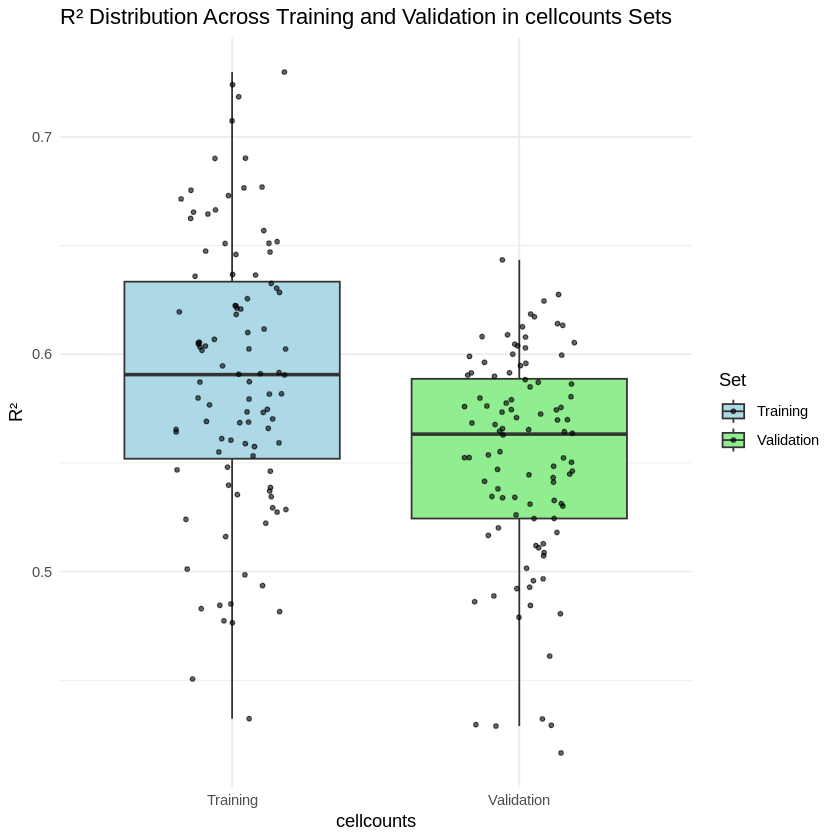

In [14]:
 plot_data_r2 <- data.frame(
  Set = rep(c("Training", "Validation"), each = 100),
  R2 = c(train_r2_values, val_r2_values)
)                                            
# Plot only R²
ppi <- 300
# png("/vol/projects/yzhang/500FG_aging/output/12_prediction/cellcounts_predicition_pvalue_common_select_spearman.png", 
#     width = 5 * ppi, height = 4 * ppi, res = ppi)

g<-ggplot(plot_data_r2, aes(x = Set, y = R2, fill = Set)) +
  geom_boxplot(outlier.shape = NA) +  # Boxplot without outliers
  geom_jitter(position = position_jitterdodge(), size = 1, alpha = 0.6, color = "black") +  # Scatter points
  labs(title = "R² Distribution Across Training and Validation in cellcounts Sets",
       x = "cellcounts",
       y = "R²") +
  theme_minimal() +
  scale_fill_manual(values = c("lightblue", "lightgreen")) +
  theme(axis.text.x = element_text(angle = 0, hjust = 0.5))
print(g)
# dev.off()    
# print(g)

In [5]:
##perform 100 times
# Custom function to train and evaluate the model with feature selection
train_and_evaluate <- function(data, seed) {
  set.seed(seed)
  
  # Step 1: Split data into training and validation sets
  splitSample <- createDataPartition(data$Age, p = 0.7, list = FALSE)
  training <- data[splitSample, ]
  validation <- data[-splitSample, ]
  
  # Step 2: Feature Selection on Training Set using Spearman correlation
  # Calculate Spearman correlation for each feature with 'Age'
  spearman_corr <- apply(training[, -which(names(training) == "Age")], 2, 
                         function(x) cor(x, training$Age, method = "spearman"))
  
  # Select features with |correlation| > 0.3 (threshold can be adjusted)
  selected_features <- names(spearman_corr[abs(spearman_corr) > 0.05])
 
if (length(selected_features) == 0) {
  stop("No features selected after Spearman correlation filtering.")
}
  # Step 3: Subset training and validation data to selected features
  training_selected <- training[, c(selected_features, "Age"), drop = FALSE]
  validation_selected <- validation[, c(selected_features, "Age"), drop = FALSE]
  
                         
  # Step 4: Set up the grid for hyperparameter tuning
  netGrid <- expand.grid(.alpha = 1, .lambda = seq(0, 1, by = 0.01))  
  netctrl <- trainControl(method = "repeatedcv", number = 10, repeats = 5) 
  
  # Step 5: Train the model using selected features
  netFit <- train(Age ~ ., data = training_selected, method = "glmnet", metric = "RMSE",
                  tuneGrid = netGrid, trControl = netctrl, preProcess = "scale")
  
  # Step 6: Make predictions on training and validation sets
  train_predictions <- predict(netFit, newdata = training_selected)
  val_predictions <- predict(netFit, newdata = validation_selected)
  
  # Step 7: Compute performance metrics for training set
  train_rmse <- sqrt(mean((training_selected$Age - train_predictions)^2))  # RMSE
  train_mse <- mean((training_selected$Age - train_predictions)^2)         # MSE
  train_r_squared <- cor(training_selected$Age, train_predictions)^2       # R²
  
  # Step 8: Compute performance metrics for validation set
  val_rmse <- sqrt(mean((validation_selected$Age - val_predictions)^2))    # RMSE
  val_mse <- mean((validation_selected$Age - val_predictions)^2)           # MSE
  val_r_squared <- cor(validation_selected$Age, val_predictions)^2         # R²
  
  # Return metrics and selected features
  list(
    train_RMSE = train_rmse,
    train_MSE = train_mse,
    train_R2 = train_r_squared,
    val_RMSE = val_rmse,
    val_MSE = val_mse,
    val_R2 = val_r_squared,
    selected_features = selected_features,  
    best_model = netFit
  )
}

In [6]:
# Run the training process 100 times
set.seed(1)
results <- lapply(1:100, function(i) train_and_evaluate(cellCounts_age, seed = i))

# Extract metrics for training and validation sets
train_rmse_values <- sapply(results, function(x) x$train_RMSE)
train_mse_values <- sapply(results, function(x) x$train_MSE)
train_r2_values <- sapply(results, function(x) x$train_R2)

val_rmse_values <- sapply(results, function(x) x$val_RMSE)
val_mse_values <- sapply(results, function(x) x$val_MSE)
val_r2_values <- sapply(results, function(x) x$val_R2)
                        
# Extract number of selected features for each iteration
num_selected_features <- sapply(results, function(x) length(x$selected_features))
                                
# Calculate mean and standard deviation for each metric
metrics_summary <- data.frame(
  Metric = c("Train RMSE", "Validation RMSE", 
             "Train MSE", "Validation MSE", 
             "Train R²", "Validation R²",
             "Number of Selected Features"),
  Mean = c(mean(train_rmse_values), mean(val_rmse_values),
           mean(train_mse_values), mean(val_mse_values),
           mean(train_r2_values), mean(val_r2_values),
           mean(num_selected_features, na.rm = TRUE)), 
  SD = c(sd(train_rmse_values), sd(val_rmse_values),
         sd(train_mse_values), sd(val_mse_values),
         sd(train_r2_values), sd(val_r2_values),
         sd(num_selected_features, na.rm = TRUE)) 
)
                              
# Print summary
print(metrics_summary)

                       Metric       Mean         SD
1                  Train RMSE  7.2548669 0.32168152
2             Validation RMSE  8.1846405 0.41191698
3                   Train MSE 52.7355382 4.66533600
4              Validation MSE 67.1563196 6.73730822
5                    Train R²  0.7177659 0.02492785
6               Validation R²  0.6495366 0.03961577
7 Number of Selected Features 56.0100000 2.60339716


In [15]:
save.image("/vol/projects/yzhang/500FG_aging/output/07_cellcounts/cellcounts_prediction(lessrawdata)_spearman_gender.Rdata")